# Assignment 3: Bus Mapping via Network Structure

Objective: map each Dayzer bus to its corresponding Panorama bus using an interpretable, graph-aware entity-resolution workflow.

Buses are electrical nodes. Branches are edges. The two datasets can be understood as different maps of the same electrical city: individual labels may differ, but physical location, voltage, and local network neighborhoods help identify the same underlying asset.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'Assignment 3 - bus_mapping').exists():
            return candidate
    raise FileNotFoundError('Could not locate ECESIS repo root containing Assignment 3 data.')

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
SRC_DIR = REPO_ROOT / 'solution' / 'assignment_3' / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from evaluation import bus_diagnostics, coordinate_diagnostics, inspect_table
from graph_features import build_graph_from_branches, endpoint_validity, graph_fingerprints
from matching import run_pipeline
from diagnostics import run_diagnostics
from normalize import standardize_bus_table

DATA_DIR = REPO_ROOT / 'data' / 'Assignment 3 - bus_mapping'
OUTPUT_DIR = REPO_ROOT / 'solution' / 'assignment_3' / 'outputs'
REPORT_DIR = REPO_ROOT / 'solution' / 'assignment_3' / 'reports'

print('Repo root:', REPO_ROOT)
print('Data dir exists:', DATA_DIR.exists())

Repo root: /Users/kikkiliu/Documents/New project/ECESIS
Data dir exists: True


## 1. Load and Inspect Data

This section loads the four provided files and records the basic shape of the problem: row counts, columns, missingness, unique buses, coordinate coverage, duplicates, voltage distributions, and branch endpoint validity.

In [2]:
dayzer_bus_raw = pd.read_csv(DATA_DIR / 'DAYZER_BUS_GEO.csv')
pano_bus_raw = pd.read_csv(DATA_DIR / 'PANO_BUS_GEO.csv')
dayzer_branch = pd.read_csv(DATA_DIR / 'DAYZER_BRANCH.csv')
pano_branch = pd.read_csv(DATA_DIR / 'PANO_BRANCH.csv')

tables = {
    'DAYZER_BUS_GEO': dayzer_bus_raw,
    'PANO_BUS_GEO': pano_bus_raw,
    'DAYZER_BRANCH': dayzer_branch,
    'PANO_BRANCH': pano_branch,
}

pd.DataFrame([inspect_table(df, name) for name, df in tables.items()])

,table,row_count,column_count,columns,missing_values
0,DAYZER_BUS_GEO,10799,8,"[MDB_ID, NAME, BASKV, IDE, AREA_NAME, ZONE_NAM...","{'MDB_ID': 0, 'NAME': 0, 'BASKV': 0, 'IDE': 0,..."
1,PANO_BUS_GEO,10233,9,"[NAME, BASKV, BUS_TYPE, AREA_NAME, ZONE_NAME, ...","{'NAME': 0, 'BASKV': 0, 'BUS_TYPE': 0, 'AREA_N..."
2,DAYZER_BRANCH,13621,15,"[MDB_ID, NAME, BRANCH_TYPE, FROM_BUS, TO_BUS, ...","{'MDB_ID': 0, 'NAME': 17, 'BRANCH_TYPE': 0, 'F..."
3,PANO_BRANCH,11267,16,"[NAME, BRANCH_TYPE, FROM_BUS_ID, FROM_BUS_KV, ...","{'NAME': 0, 'BRANCH_TYPE': 0, 'FROM_BUS_ID': 0..."


In [3]:
for name, df in tables.items():
    print(f'\n{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
    display(df.head(3))


DAYZER_BUS_GEO: 10,799 rows x 8 columns


,MDB_ID,NAME,BASKV,IDE,AREA_NAME,ZONE_NAME,LAT,LON
0,1,ROANSPRARE,138.0,1,BEPC_TSP,BEPC_GRIMES,30.584801,-95.934303
1,1,KEITHSW,138.0,1,BEPC_TSP,BEPC_GRIMES,30.650999,-96.089996
2,1,IOLA,138.0,1,BEPC_TSP,BEPC_GRIMES,30.730000,-96.044998



PANO_BUS_GEO: 10,233 rows x 9 columns


,NAME,BASKV,BUS_TYPE,AREA_NAME,ZONE_NAME,LAT,LON,PANO_ID,STATION
0,ADK_138KV_1,138.0,LOAD,ERC,COAS,29.976728,-95.594192,1,ADK
1,ADK_138KV_2,138.0,LOAD,ERC,COAS,29.976539,-95.595559,1,ADK
2,ADK_138KV_3,138.0,ISOLATED,ERC,COAS,29.976264,-95.593649,1,ADK



DAYZER_BRANCH: 13,621 rows x 15 columns


,MDB_ID,NAME,BRANCH_TYPE,FROM_BUS,TO_BUS,FROM_KV,TO_KV,CKT,R,X,B,SRATEA,SRATEB,WRATEA,WRATEB
0,1,1021 MIDLET_5 1185 MIDCONW_ 1,LN,MIDLET_5,MIDCONW_5,345.0,345.0,1,0.000941,0.008197,0.153672,1072.000000,1072.000000,1072.000000,1072.000000
1,1,1018 MOSS_5 11028 ODESEHV 1,LN,MOSS_5,ODESEHV2_5,345.0,345.0,1,0.000414,0.007524,0.150308,2987.787643,3070.250582,2987.787643,3070.250582
2,1,1019 MOSS_8 1129 WESTOVER 1,LN,MOSS_8,WESTOVER_8,138.0,138.0,1,0.002030,0.013495,0.003760,394.000000,394.000000,394.000000,394.000000



PANO_BRANCH: 11,267 rows x 16 columns


,NAME,BRANCH_TYPE,FROM_BUS_ID,FROM_BUS_KV,TO_BUS_ID,TO_BUS_KV,CIRCUIT,R,X,B,RATE_A,RATE_B,RATE_C,FROM_BUS_NAME,TO_BUS_NAME,PANO_ID
0,0165_1,LN,5024,345.0,5116,345.0,1,0.00046,0.00696,0.14096,1480.00,1483.00,1793.00,W_DENT_345KV_1,RNKSW_345KV_1,1
1,100016_1,LN,4942,138.0,6139,138.0,1,0.00001,0.00050,0.00000,281.29,281.29,300.11,LVOAK_138KV_1,LIVEOAK_138KV_1,1
2,100018_1_,LN,5880,69.0,5894,69.0,1,0.00001,0.00050,0.00000,87.00,87.00,100.85,ORANS_69KV_1,ORN_69KV_1,1


## 2. Coordinate EDA Before Matching

Because the first-stage candidate generation uses latitude and longitude, this check happens before matching. The goal is to confirm that coordinates are mostly present and physically plausible, and to document any fallback cases where the algorithm must rely more heavily on name and voltage evidence.

This EDA checks:

- missing latitude and longitude values
- coordinate coverage percentage
- invalid non-missing coordinate ranges
- zero coordinates
- duplicate coordinates
- latitude and longitude ranges

In [4]:
coordinate_eda = pd.DataFrame([
    coordinate_diagnostics(dayzer_bus_raw, 'dayzer'),
    coordinate_diagnostics(pano_bus_raw, 'pano'),
])
coordinate_eda

,source,row_count,missing_latitude,missing_longitude,missing_either_coordinate,coordinate_coverage_pct,invalid_nonmissing_coordinate_range,zero_coordinate_rows,duplicate_coordinate_rows,latitude_min,latitude_max,longitude_min,longitude_max
0,dayzer,10799,681,681,681,93.69,0,0,3305,25.889099,35.623001,-104.814697,-94.352097
1,pano,10233,0,0,0,100.00,0,0,0,25.910143,35.654208,-104.537855,-94.358537


In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
coordinate_eda.to_csv(OUTPUT_DIR / 'coordinate_diagnostics.csv', index=False)

for _, row in coordinate_eda.iterrows():
    coverage = row['coordinate_coverage_pct']
    missing = row['missing_either_coordinate']
    source = row['source']
    if coverage < 90:
        warnings.warn(f'{source} coordinate coverage is below 90%: {coverage:.2f}%')
    else:
        print(f'{source}: {coverage:.2f}% coordinate coverage; {missing:,} rows missing at least one coordinate.')

dayzer: 93.69% coordinate coverage; 681 rows missing at least one coordinate.
pano: 100.00% coordinate coverage; 0 rows missing at least one coordinate.


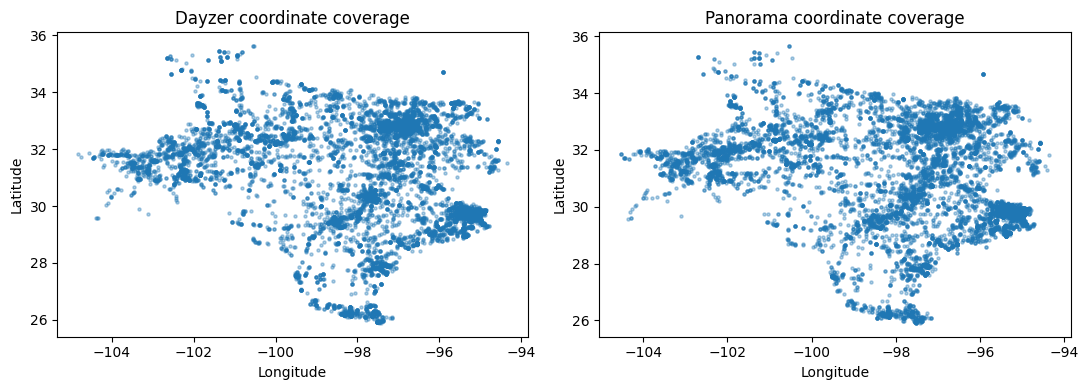

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (label, df) in zip(axes, [('Dayzer', dayzer_bus_raw), ('Panorama', pano_bus_raw)]):
    valid = df['LAT'].notna() & df['LON'].notna()
    ax.scatter(df.loc[valid, 'LON'], df.loc[valid, 'LAT'], s=5, alpha=0.35)
    ax.set_title(f'{label} coordinate coverage')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
plt.tight_layout()

## 3. Normalization

The normalization is intentionally conservative: lowercase text, replace separators with spaces, remove punctuation, standardize whitespace, and preserve numeric identifiers and voltage-like tokens. This avoids collapsing buses that differ only by circuit or bus number.

In [7]:
dayzer_bus = standardize_bus_table(dayzer_bus_raw, 'dayzer')
pano_bus = standardize_bus_table(pano_bus_raw, 'pano')

bus_diag = pd.DataFrame([
    bus_diagnostics(dayzer_bus, 'dayzer'),
    bus_diagnostics(pano_bus, 'pano'),
])
bus_diag

,source,row_count,unique_bus_names,duplicate_bus_names,lat_lon_coverage,duplicate_coordinates,kv_distribution
0,dayzer,10799,10558,241,0.936939,3985,"{0.48: 1, 1.0: 394, 2.4: 1, 4.0: 2, 4.16: 2, 4..."
1,pano,10233,10233,0,1.000000,0,"{0.48: 1, 1.0: 389, 2.4: 1, 4.0: 2, 4.16: 2, 4..."


In [8]:
display(dayzer_bus.head())
display(pano_bus.head())

,dayzer_bus_id,raw_bus_name,normalized_bus_name,voltage_kv,latitude,longitude,bus_source,voltage_band,name_tokens,numeric_tokens
0,1_0,ROANSPRARE,roansprare,138.0,30.584801,-95.934303,dayzer,hv,roansprare,
1,1_1,KEITHSW,keithsw,138.0,30.650999,-96.089996,dayzer,hv,keithsw,
2,1_2,IOLA,iola,138.0,30.730000,-96.044998,dayzer,hv,iola,
3,1_3,SANDYSW,sandysw,138.0,30.636400,-95.954300,dayzer,hv,sandysw,
4,1_4,HWY6,hwy6,138.0,30.440500,-96.130600,dayzer,hv,hwy6,6


,pano_bus_id,raw_bus_name,normalized_bus_name,voltage_kv,latitude,longitude,bus_source,voltage_band,name_tokens,numeric_tokens
0,1_0,ADK_138KV_1,adk 138kv 1,138.0,29.976728,-95.594192,pano,hv,1 138kv adk,1 138
1,1_1,ADK_138KV_2,adk 138kv 2,138.0,29.976539,-95.595559,pano,hv,138kv 2 adk,138 2
2,1_2,ADK_138KV_3,adk 138kv 3,138.0,29.976264,-95.593649,pano,hv,138kv 3 adk,138 3
3,1_3,ADK_345KV_1,adk 345kv 1,345.0,29.975780,-95.593327,pano,ehv,1 345kv adk,1 345
4,1_4,ADK_345KV_2,adk 345kv 2,345.0,29.975604,-95.592091,pano,ehv,2 345kv adk,2 345


## 4. Spatial Candidate Generation

Latitude and longitude are used as first-stage candidate filtering. For each Dayzer bus, the pipeline keeps Panorama buses within a configurable radius and also includes nearest-neighbor fallbacks. If coordinates are missing, the fallback uses name and voltage evidence.

Default configuration: `radius_km = 20`, `top_k = 10`.

In [9]:
outputs = run_pipeline(REPO_ROOT, radius_km=20.0, top_k=10, min_score=0.45, use_propagation=True)

candidates = outputs['candidates']
scored = outputs['scored_candidates']
baseline_results = outputs['baseline_results']
seed_matches = outputs['seed_matches']
accepted_matches = outputs['accepted_matches']
propagated_candidates = outputs['propagated_candidates']
propagation_log = outputs['propagation_log']
results = outputs['results']
manual_review = outputs['manual_review']

print('Candidate pairs:', f'{len(candidates):,}')
print('Baseline matched:', f"{baseline_results['pano_bus'].notna().sum():,}")
print('Strict seeds:', f'{len(seed_matches):,}')
print('Accepted graph matches:', f'{len(accepted_matches):,}')
print('Final result rows:', f'{len(results):,}')
print('Saved outputs to:', OUTPUT_DIR)

Candidate pairs: 892,106
Baseline matched: 6,285
Strict seeds: 49
Accepted graph matches: 1,059
Final result rows: 10,799
Saved outputs to: /Users/kikkiliu/Documents/New project/ECESIS/solution/assignment_3/outputs


In [10]:
candidate_cols = ['dayzer_bus_id', 'dayzer_bus_name', 'pano_bus_id', 'pano_bus_name', 'distance_km', 'dayzer_kv', 'pano_kv']
candidates[candidate_cols].head(10)

,dayzer_bus_id,dayzer_bus_name,pano_bus_id,pano_bus_name,distance_km,dayzer_kv,pano_kv
0,1_0,ROANSPRARE,1_6833,FTR_22KV_1,1.741062,138.0,22.0
1,1_0,ROANSPRARE,1_6834,FTR_18KV_1,1.774686,138.0,18.0
2,1_0,ROANSPRARE,1_6835,FTR_18KV_2,1.787420,138.0,18.0
3,1_0,ROANSPRARE,1_6837,FTR_345KV_1,1.806820,138.0,345.0
4,1_0,ROANSPRARE,1_6836,FTR_18KV_3,1.850068,138.0,18.0
5,1_0,ROANSPRARE,1_6687,RPR_138KV_1,2.637798,138.0,138.0
6,1_0,ROANSPRARE,1_6901,SANDYSW_138KV_1,5.407270,138.0,138.0
7,1_0,ROANSPRARE,1_6847,SNG_345KV_1,11.473469,138.0,345.0
8,1_0,ROANSPRARE,1_6592,GIBCRK_138KV_2,12.201983,138.0,138.0
9,1_0,ROANSPRARE,1_6598,GIBCRK_12KV_2,12.301565,138.0,12.4


## 5. Attribute Similarity Features

Every candidate pair receives name, voltage, geographic, and rank features. Name scoring combines fuzzy string similarity, token overlap, and numeric-token overlap. Voltage scoring gives strongest credit to exact kV matches and partial credit to same-band matches.

In [11]:
feature_cols = [
    'dayzer_bus_name', 'pano_bus_name', 'distance_km', 'distance_score',
    'fuzzy_name_similarity', 'token_overlap', 'numeric_token_overlap', 'name_score',
    'exact_voltage_match', 'voltage_difference', 'same_voltage_band', 'voltage_score',
    'distance_rank', 'name_rank', 'voltage_compatible_rank',
]
scored[feature_cols].head(10)

,dayzer_bus_name,pano_bus_name,distance_km,distance_score,fuzzy_name_similarity,token_overlap,numeric_token_overlap,name_score,exact_voltage_match,voltage_difference,same_voltage_band,voltage_score,distance_rank,name_rank,voltage_compatible_rank
5,ROANSPRARE,RPR_138KV_1,2.637798,0.876437,0.285714,0.0,0.0,0.171429,True,0.0,True,1.0,6,1,1
6,ROANSPRARE,SANDYSW_138KV_1,5.407270,0.763102,0.240000,0.0,0.0,0.144000,True,0.0,True,1.0,7,2,2
17,ROANSPRARE,CRTCHFLD_138KV_1,12.383528,0.538388,0.076923,0.0,0.0,0.046154,True,0.0,True,1.0,18,27,5
23,ROANSPRARE,KEI_138KV_1,18.265074,0.401217,0.095238,0.0,0.0,0.057143,True,0.0,True,1.0,24,13,9
21,ROANSPRARE,CARLOSSW_138KV_1,16.539594,0.437368,0.153846,0.0,0.0,0.092308,True,0.0,True,1.0,22,4,7
8,ROANSPRARE,GIBCRK_138KV_2,12.201983,0.543297,0.083333,0.0,0.0,0.050000,True,0.0,True,1.0,9,20,3
20,ROANSPRARE,CAR_138KV_1,15.599521,0.458417,0.190476,0.0,0.0,0.114286,True,0.0,True,1.0,21,3,6
13,ROANSPRARE,GIBCRK_138KV_1,12.344786,0.539432,0.083333,0.0,0.0,0.050000,True,0.0,True,1.0,14,21,4
25,ROANSPRARE,BLUEJAY_138KV_1,18.786387,0.390894,0.080000,0.0,0.0,0.048000,True,0.0,True,1.0,26,26,10
22,ROANSPRARE,KEITHSW_138KV_1,17.399028,0.418972,0.080000,0.0,0.0,0.048000,True,0.0,True,1.0,23,25,8


## 6. Graph / Network Features

Branches are converted into undirected graphs. For each bus, local fingerprints include degree, neighbor counts, neighbor voltage profiles, and neighbor name tokens. Candidate pairs are then compared using degree similarity, neighbor-voltage overlap, and neighbor-token overlap.

Topology is used as a refinement signal rather than a replacement for spatial, name, and voltage evidence.

In [12]:
dayzer_graph = build_graph_from_branches(dayzer_branch, dayzer_bus, 'dayzer')
pano_graph = build_graph_from_branches(pano_branch, pano_bus, 'pano')

endpoint_summary = pd.DataFrame({
    'dayzer': endpoint_validity(dayzer_branch, dayzer_bus, 'dayzer'),
    'pano': endpoint_validity(pano_branch, pano_bus, 'pano'),
}).T
endpoint_summary

,endpoint_count,valid_endpoint_count,invalid_endpoint_count
dayzer,27242,27242,0
pano,22534,22534,0


In [13]:
dayzer_graph_features = graph_fingerprints(dayzer_bus, dayzer_graph, 'dayzer')
pano_graph_features = graph_fingerprints(pano_bus, pano_graph, 'pano')

display(dayzer_graph_features.head())
display(pano_graph_features.head())

,dayzer_bus_id,degree,neighbor_count,same_voltage_neighbor_count,high_voltage_neighbor_count,low_voltage_neighbor_count,neighbor_voltage_profile,neighbor_name_tokens
0,1_1865,1,1,1,0,0,{'hv': 1},elevee w8
1,1_9292,1,1,1,0,0,{'lv': 1},g871 lncrk2
2,1_493,2,2,2,0,0,{'hv': 2},dmenode gis hk
3,1_1628,3,3,3,0,0,{'hv': 3},8 bloomdale mckny1 mcknywht t8
4,1_10421,2,2,1,1,0,"{'hv': 1, 'lv': 1}",1 3 phoebe


,pano_bus_id,degree,neighbor_count,same_voltage_neighbor_count,high_voltage_neighbor_count,low_voltage_neighbor_count,neighbor_voltage_profile,neighbor_name_tokens
0,1_1865,7,7,3,0,4,"{'hv': 1, 'lv': 3, 'ehv': 3}",1 138kv 1kv 2 3 345kv cagnon hillctry howard k...
1,1_9292,2,2,1,1,0,{'hv': 2},1 138kv luna nebula
2,1_493,1,1,1,0,0,{'hv': 1},1 138kv joslin
3,1_1628,3,3,1,0,2,{'hv': 3},1 138kv 2 han phr sbk
4,1_6215,4,4,4,0,0,{'hv': 4},1 138kv 2 norsw slotm wlvee wntwk


In [14]:
topology_cols = [
    'dayzer_bus_name', 'pano_bus_name', 'degree_dayzer', 'degree_pano',
    'degree_similarity', 'neighbor_voltage_overlap', 'neighbor_token_overlap', 'topology_score',
]
scored[topology_cols].head(10)

,dayzer_bus_name,pano_bus_name,degree_dayzer,degree_pano,degree_similarity,neighbor_voltage_overlap,neighbor_token_overlap,topology_score
5,ROANSPRARE,RPR_138KV_1,2,2,1.000000,1.000000,0.142857,0.828571
6,ROANSPRARE,SANDYSW_138KV_1,2,3,0.666667,0.666667,0.000000,0.533333
17,ROANSPRARE,CRTCHFLD_138KV_1,2,2,1.000000,1.000000,0.142857,0.828571
23,ROANSPRARE,KEI_138KV_1,2,2,1.000000,1.000000,0.000000,0.800000
21,ROANSPRARE,CARLOSSW_138KV_1,2,3,0.666667,0.666667,0.000000,0.533333
8,ROANSPRARE,GIBCRK_138KV_2,2,1,0.500000,0.500000,0.000000,0.400000
20,ROANSPRARE,CAR_138KV_1,2,1,0.500000,0.500000,0.000000,0.400000
13,ROANSPRARE,GIBCRK_138KV_1,2,6,0.333333,0.333333,0.000000,0.266667
25,ROANSPRARE,BLUEJAY_138KV_1,2,3,0.666667,0.250000,0.000000,0.387500
22,ROANSPRARE,KEITHSW_138KV_1,2,5,0.400000,0.400000,0.000000,0.320000


## 7. Composite Score, Propagation, and Match Selection

The baseline composite score combines geographic distance, voltage compatibility, name similarity, and local topology. The implemented graph-aware model then adds a seed-and-propagate layer:

1. Select strict high-confidence seed matches.
2. Use matched Dayzer neighbors and Panorama neighbors to calculate propagation support.
3. Iteratively accept one-to-one candidates with strong propagation score, sufficient support, and compatible voltage.
4. Preserve weaker top-ranked candidates as review candidates while flagging one-to-one conflicts and ambiguity.

This makes topology an active matching signal rather than only a static diagnostic feature.

In [15]:
summary = {
    'dayzer_buses': len(dayzer_bus),
    'pano_buses': len(pano_bus),
    'candidate_pairs': len(candidates),
    'baseline_matched': int(baseline_results['pano_bus'].notna().sum()),
    'strict_seed_matches': int(len(seed_matches)),
    'accepted_graph_matches': int(len(accepted_matches)),
    'final_matched_after_one_to_one': int(results['pano_bus'].notna().sum()),
    'final_unmatched_or_conflict': int(results['pano_bus'].isna().sum()),
    'one_to_one_conflicts': int(results.get('one_to_one_conflict_flag', pd.Series(False, index=results.index)).sum()),
    'duplicate_nonblank_pano_ids': int(results['pano_bus_id'].dropna().duplicated().sum()),
    'ambiguity_rate': float(results['ambiguity_flag'].mean()),
}
summary

{'dayzer_buses': 10799,
 'pano_buses': 10233,
 'candidate_pairs': 892106,
 'baseline_matched': 6285,
 'strict_seed_matches': 49,
 'accepted_graph_matches': 1059,
 'final_matched_after_one_to_one': 5982,
 'final_unmatched_or_conflict': 4817,
 'one_to_one_conflicts': 2993,
 'duplicate_nonblank_pano_ids': 0,
 'ambiguity_rate': 0.7453467913695713}

In [16]:
results['confidence_label'].value_counts(dropna=False)

confidence_label
ambiguous    8049
low          1467
high          865
medium        418
Name: count, dtype: int64

In [17]:
result_cols = [
    'dayzer_bus', 'pano_bus', 'match_stage', 'accepted_graph_match',
    'dayzer_kv', 'pano_kv', 'distance_km',
    'name_score', 'voltage_score', 'topology_score', 'composite_score',
    'propagation_score', 'propagation_support_count',
    'confidence_label', 'ambiguity_flag', 'one_to_one_conflict_flag',
]
results[result_cols].head(20)

,dayzer_bus,pano_bus,match_stage,accepted_graph_match,dayzer_kv,pano_kv,distance_km,name_score,voltage_score,topology_score,composite_score,propagation_score,propagation_support_count,confidence_label,ambiguity_flag,one_to_one_conflict_flag
8280,DOWGEN_11_8,<NA>,one_to_one_conflict,False,138.0,138.0,1.070850,0.655000,1.0,0.800000,0.858110,0.947839,1,ambiguous,True,True
8518,CBEC_STG1,<NA>,one_to_one_conflict,False,13.8,13.8,0.194293,0.497500,1.0,0.900000,0.851475,0.943062,1,ambiguous,True,True
8273,DOWGEN_7_8,<NA>,one_to_one_conflict,False,138.0,138.0,1.070850,0.625000,1.0,0.800000,0.850610,0.942439,1,ambiguous,True,True
8277,DOWGEN_9_8,<NA>,one_to_one_conflict,False,138.0,138.0,1.070850,0.625000,1.0,0.800000,0.850610,0.942439,1,ambiguous,True,True
8521,CBEC_STG2,<NA>,one_to_one_conflict,False,13.8,13.8,0.311996,0.497500,1.0,0.900000,0.849731,0.941807,1,ambiguous,True,True
8524,CBEC_GT11,<NA>,one_to_one_conflict,False,13.8,13.8,0.194293,0.482500,1.0,0.900000,0.847725,0.940362,1,ambiguous,True,True
8525,CBEC_GT12,<NA>,one_to_one_conflict,False,13.8,13.8,0.311996,0.482500,1.0,0.900000,0.845981,0.939107,1,ambiguous,True,True
8237,CBY4_CT42,<NA>,one_to_one_conflict,False,16.0,16.0,0.117106,0.460000,1.0,0.900000,0.843249,0.937139,1,ambiguous,True,True
8238,CBY4_ST04,<NA>,one_to_one_conflict,False,16.0,16.0,0.117106,0.400000,1.0,0.900000,0.828249,0.926339,1,ambiguous,True,True
10001,JCKCNTY2_CT3,<NA>,one_to_one_conflict,False,18.0,18.0,0.818462,0.512500,1.0,0.800000,0.826096,0.924789,1,ambiguous,True,True


## 8. Topology-Aware Propagation Diagnostics

The propagation log shows how strict seed matches expand into graph-supported matches. Iteration 0 contains the initial high-confidence seeds; later iterations contain matches accepted because their already-matched neighbors align with the candidate Panorama neighborhood.

In [18]:
propagation_log

,iteration,accepted_this_iteration,total_accepted,stage
0,0,49,49,seed
1,1,66,115,propagation
2,2,71,186,propagation
3,3,92,278,propagation
4,4,127,405,propagation
5,5,157,562,propagation
6,6,159,721,propagation
7,7,168,889,propagation
8,8,170,1059,propagation


In [19]:
results['match_stage'].value_counts(dropna=False)

match_stage
top_ranked_unpropagated    4923
one_to_one_conflict        2993
unmatched                  1824
propagated                 1010
seed                         49
Name: count, dtype: int64

In [20]:
accepted_matches[[
    'dayzer_bus_name', 'pano_bus_name', 'match_stage', 'propagation_iteration',
    'propagation_support_count', 'propagation_support_ratio', 'propagation_score',
    'composite_score', 'voltage_score', 'distance_km'
]].sort_values(['propagation_iteration', 'propagation_score'], ascending=[True, False]).head(20)

,dayzer_bus_name,pano_bus_name,match_stage,propagation_iteration,propagation_support_count,propagation_support_ratio,propagation_score,composite_score,voltage_score,distance_km
0,DEC_1_1,DEC_1KV_1,seed,0,0,0.0,0.917228,0.917228,1.0,0.821806
1,LPNSW_13_1,LPNSW_13KV_1,seed,0,0,0.0,0.885035,0.885035,1.0,4.193485
2,DOWGEN_8_8,DOWGEN_138KV_8,seed,0,0,0.0,0.879776,0.879776,1.0,1.070850
3,AZURE_T1,AZURE_1KV_1,seed,0,0,0.0,0.878520,0.878520,1.0,0.008745
4,RTS2_5_1,RTS2_345KV_1,seed,0,0,0.0,0.877878,0.877878,1.0,0.747878
5,CITYVICT_138,CITYVICT_138KV_1,seed,0,0,0.0,0.877100,0.877100,1.0,0.019414
6,QUEEN_BA_G1,QUEEN_BA_34KV_1,seed,0,0,0.0,0.876688,0.876688,1.0,0.571219
7,CHALUPA_138,CHALUPA_138KV_1,seed,0,0,0.0,0.875935,0.875935,1.0,0.024190
8,GRSES1_1,GRSES_1KV_1,seed,0,0,0.0,0.873189,0.873189,1.0,0.030878
9,ELMOT1_1,ELMOT_1KV_1,seed,0,0,0.0,0.872295,0.872295,1.0,0.090609


## 9. Manual Review Samples

The manual review file includes samples from high-confidence, medium-confidence, ambiguous, and low/unmatched buckets. This supports human validation and future supervised refinement.

In [21]:
manual_review[['review_bucket', 'dayzer_bus', 'pano_bus', 'composite_score', 'confidence_label', 'ambiguity_flag']].head(30)

,review_bucket,dayzer_bus,pano_bus,composite_score,confidence_label,ambiguity_flag
0,high,RIONOG_ST1,RIONOG_22KV_1,0.861965,high,False
1,high,SCLPCOGN_2_8,SCLPCOGN_138KV_1,0.836492,high,False
2,high,L_FPPYD15_1Y,FPPYD1_345KV_1,0.823786,high,False
3,high,LGDRAW_S8,LGDRAW_S_138KV_1,0.798884,high,False
4,high,LUFKNSS_3,LFKSW_13KV_1,0.780423,high,False
5,high,BCAT_WND_8,BCATWIND_138KV_1,0.780412,high,False
6,high,FTLN2A,FTLN_69KV_1,0.779164,high,False
7,high,GALVES__B138,STW_138KV_1,0.766082,high,False
8,high,L_KENDAL1_2,KENDAL_1KV_2,0.751258,high,False
9,high,POESTA0B,POESTA_1KV_1,0.748072,high,False


## 10. No Ground Truth Evaluation and Diagnostics

Because no labeled ground truth is available, evaluation focuses on internal consistency diagnostics rather than true accuracy. We assess whether mappings are electrically and operationally defensible using voltage compatibility, duplicate assignment rate, topology support, geographic plausibility, confidence labels, and manual spot-check samples.

The graph-aware method intentionally prioritizes fewer bad automatic matches over maximizing match count.

In [22]:
diagnostic_outputs = run_diagnostics(REPO_ROOT)
ablation = diagnostic_outputs['bus_mapping_ablation_results.csv']
sensitivity = diagnostic_outputs['bus_mapping_sensitivity_results.csv']
one_to_one = diagnostic_outputs['one_to_one_resolution_diagnostics.csv']
topology_contribution = diagnostic_outputs['topology_contribution_summary.csv']
distance_voltage = diagnostic_outputs['distance_voltage_diagnostics.csv']
case_studies = diagnostic_outputs['bus_mapping_case_studies.csv']
manual_review_extended = diagnostic_outputs['bus_mapping_manual_review_extended.csv']

ablation

,variant,matched_buses,unmatched_count,duplicate_pano_assignments,exact_voltage_match_rate,voltage_conflict_rate_gt_1kv,median_distance_km,p90_distance_km,ambiguity_count,ambiguity_rate
0,A_pure_latlon_nearest,10799,0,7102,0.541532,0.421984,1.836463,6.428410,9306,0.861746
1,B_name_kv_only,10799,0,4220,0.976016,0.022502,7.420158,17.274767,8228,0.761922
2,C_name_kv_latlon,10799,0,5111,0.972405,0.026762,2.708830,10.355149,9653,0.893879
3,D_graph_aware_no_propagation,6285,4514,0,0.989499,0.003819,3.402140,12.255094,7963,0.737383
4,E_full_graph_aware_final,5982,4817,0,0.987630,0.001839,3.493811,12.275837,8049,0.745347


In [23]:
sensitivity

,parameter,value,high_confidence_count,variant,matched_buses,unmatched_count,duplicate_pano_assignments,exact_voltage_match_rate,voltage_conflict_rate_gt_1kv,median_distance_km,p90_distance_km,ambiguity_count,ambiguity_rate,name_weight
0,radius_km,5.00,165,radius_km=5,9116,1683,4420,0.865292,0.127249,2.078129,4.429452,7780,0.853444,NaN
1,radius_km,10.00,165,radius_km=10,10464,335,4795,0.920776,0.073586,3.212124,8.325453,8862,0.846904,NaN
2,radius_km,20.00,165,radius_km=20,10766,33,4487,0.967490,0.027494,3.627006,12.167381,8890,0.825748,NaN
3,radius_km,50.00,165,radius_km=50,10799,0,4490,0.970090,0.025002,3.647855,12.459139,8906,0.824706,NaN
4,topology_weight,0.10,31,topology_weight=0.1,10799,0,4456,0.973979,0.023798,3.550384,12.437361,8905,0.824613,0.35
5,topology_weight,0.20,165,topology_weight=0.2,10799,0,4490,0.970090,0.025002,3.647855,12.459139,8907,0.824799,0.25
6,topology_weight,0.30,754,topology_weight=0.3,10799,0,4576,0.954903,0.036022,3.747165,12.533617,9052,0.838226,0.15
7,confidence_threshold,0.65,1288,confidence_threshold=0.65,1288,9511,0,0.972050,0.000776,5.447474,14.934672,8049,0.745347,NaN
8,confidence_threshold,0.75,1251,confidence_threshold=0.75,1251,9548,0,0.976819,0.000799,5.271262,14.698456,8049,0.745347,NaN
9,confidence_threshold,0.85,878,confidence_threshold=0.85,878,9921,0,0.985194,0.000000,2.849419,10.344177,8049,0.745347,NaN


In [24]:
display(one_to_one)
display(topology_contribution)
display(distance_voltage)

,metric,value
0,top_candidate_duplicate_pano_assignments_befor...,4490
1,baseline_duplicate_pano_assignments_after_base...,0
2,lower_scoring_duplicates_marked_conflict_or_un...,2993
3,final_duplicate_nonblank_pano_assignments,0


,metric,value
0,accepted_topology_supported_matches,1059
1,matched_high_topology_low_or_moderate_name,4575
2,matched_candidate_changed_from_latlon_nearest,4528
3,matched_small_gap_high_topology_cases,2378


,section,metric,value
0,distance,matched_mean_distance_km,4.934215
1,distance,matched_median_distance_km,3.493811
2,distance,matched_p90_distance_km,12.275837
3,distance,matched_max_distance_km,31.568198
4,distance,high_confidence_median_distance_km,2.974380
5,voltage,ambiguous_exact_voltage_match_rate,0.989790
6,voltage,ambiguous_voltage_conflict_rate_gt_1kv,0.002475
7,voltage,high_exact_voltage_match_rate,1.000000
8,voltage,high_voltage_conflict_rate_gt_1kv,0.000000
9,voltage,low_exact_voltage_match_rate,0.995228


In [25]:
manual_review_extended['review_bucket'].value_counts()

review_bucket
high_confidence                50
medium_confidence              50
ambiguous                      50
low_or_unmatched               50
topology_supported             50
latlon_disagreed_with_graph    50
Name: count, dtype: int64

In [26]:
case_studies

,case_type,dayzer_bus,pano_candidate,latlon_baseline_pano_bus,dayzer_kv,pano_kv,distance_km,name_score,topology_score,propagation_support_count,decision,reason
0,high_confidence_clean_match,LPNSW_1_2,LPNSW_1KV_2,DESSW_138KV_1,1.0,1.0,4.124314,0.815000,0.840000,3,accepted,"Strong voltage, score, and graph-aware evidence."
1,latlon_baseline_failure_fixed,LPNSW_1_2,LPNSW_1KV_2,DESSW_138KV_1,1.0,1.0,4.124314,0.815000,0.840000,3,accepted,Graph-aware final candidate differs from neare...
2,topology_rescued_weak_name,VICTPORT_8,VICTPORT_138KV_1,VICTPORT_138KV_1,138.0,138.0,0.027471,0.524038,0.888889,2,accepted,"Name evidence is moderate/weak, but voltage an..."
3,ambiguous_unresolved,BTE_2_5,BTE_345KV_2,BTE_18KV_4,345.0,345.0,0.219309,0.508333,0.844444,2,flagged,Candidate remains ambiguous because of conflic...
4,voltage_conflict_rejected,CLO_C2,CLO_34KV_2,PRO_13KV_3,34.5,34.5,7.375195,0.512500,0.500000,0,rejected_or_replaced,Nearest-coordinate candidate has voltage confl...


## 11. Visualizations

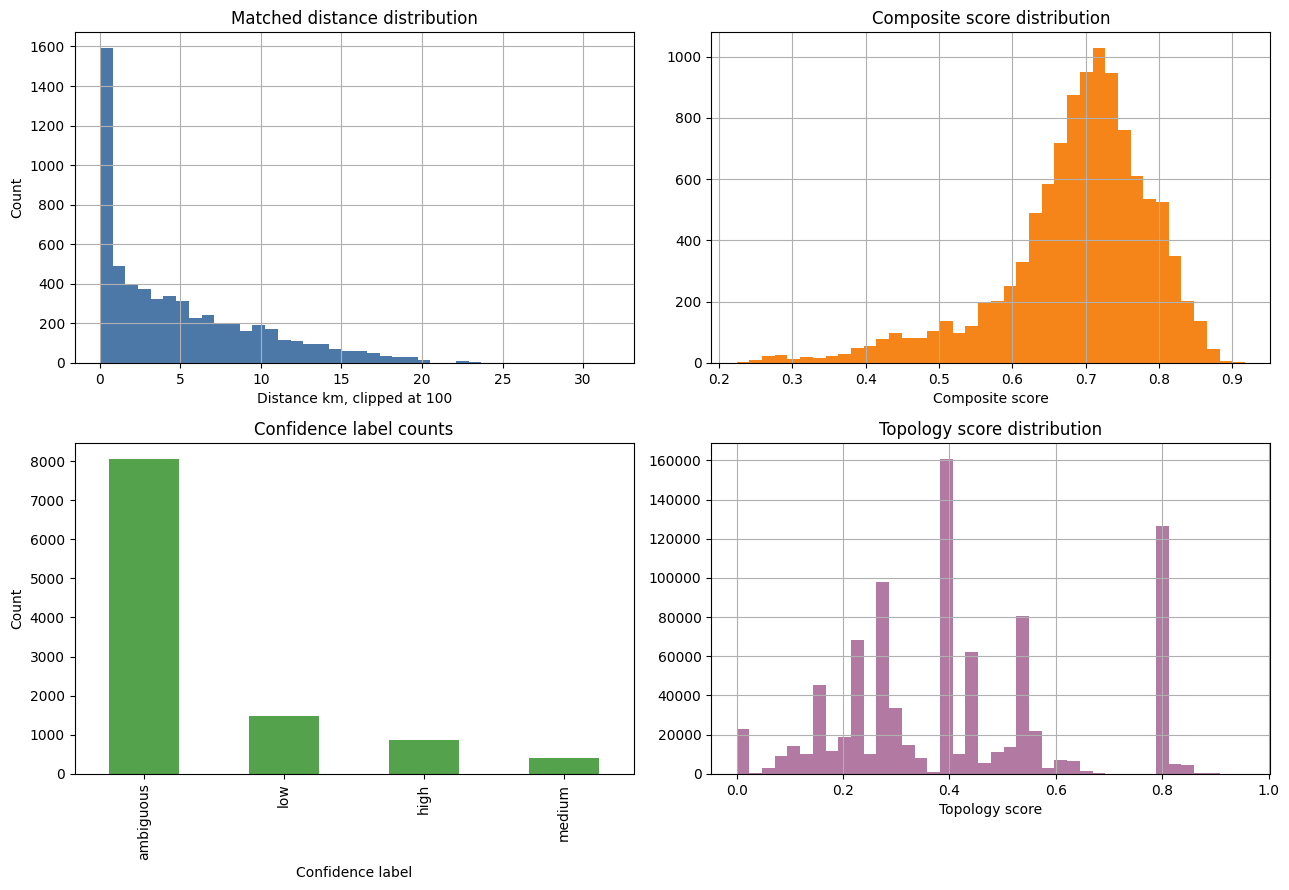

In [27]:
plt.style.use('default')

matched = results[results['pano_bus'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

matched['distance_km'].dropna().clip(upper=100).hist(bins=40, ax=axes[0], color='#4C78A8')
axes[0].set_title('Matched distance distribution')
axes[0].set_xlabel('Distance km, clipped at 100')
axes[0].set_ylabel('Count')

results['composite_score'].hist(bins=40, ax=axes[1], color='#F58518')
axes[1].set_title('Composite score distribution')
axes[1].set_xlabel('Composite score')

results['confidence_label'].value_counts().plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('Confidence label counts')
axes[2].set_xlabel('Confidence label')
axes[2].set_ylabel('Count')

scored['topology_score'].hist(bins=40, ax=axes[3], color='#B279A2')
axes[3].set_title('Topology score distribution')
axes[3].set_xlabel('Topology score')

plt.tight_layout()

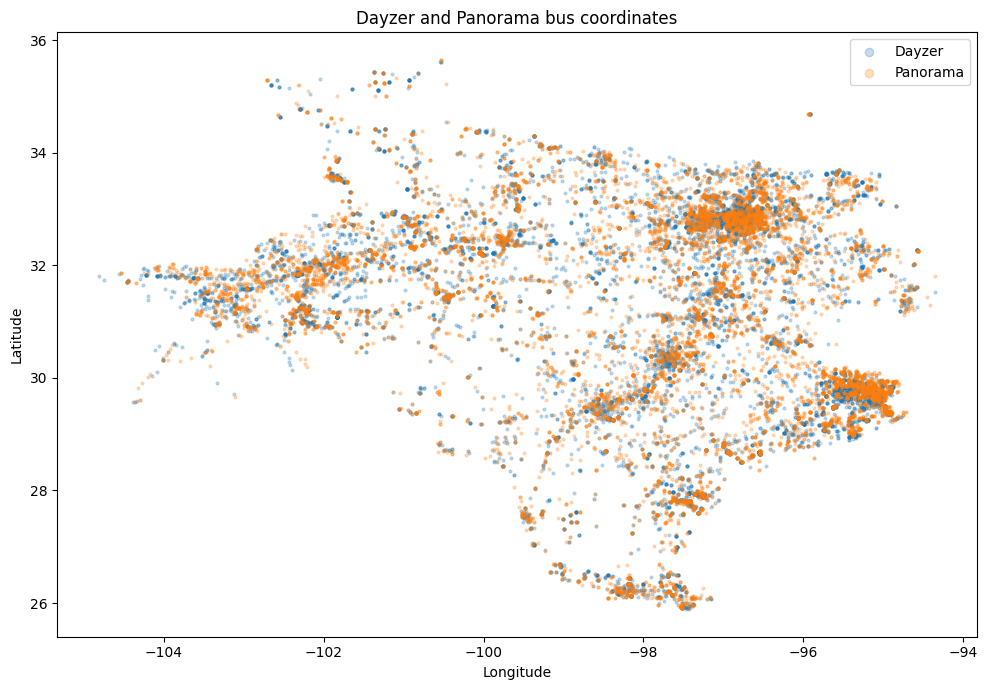

In [28]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(dayzer_bus['longitude'], dayzer_bus['latitude'], s=4, alpha=0.25, label='Dayzer')
ax.scatter(pano_bus['longitude'], pano_bus['latitude'], s=4, alpha=0.25, label='Panorama')
ax.set_title('Dayzer and Panorama bus coordinates')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=3)
plt.tight_layout()

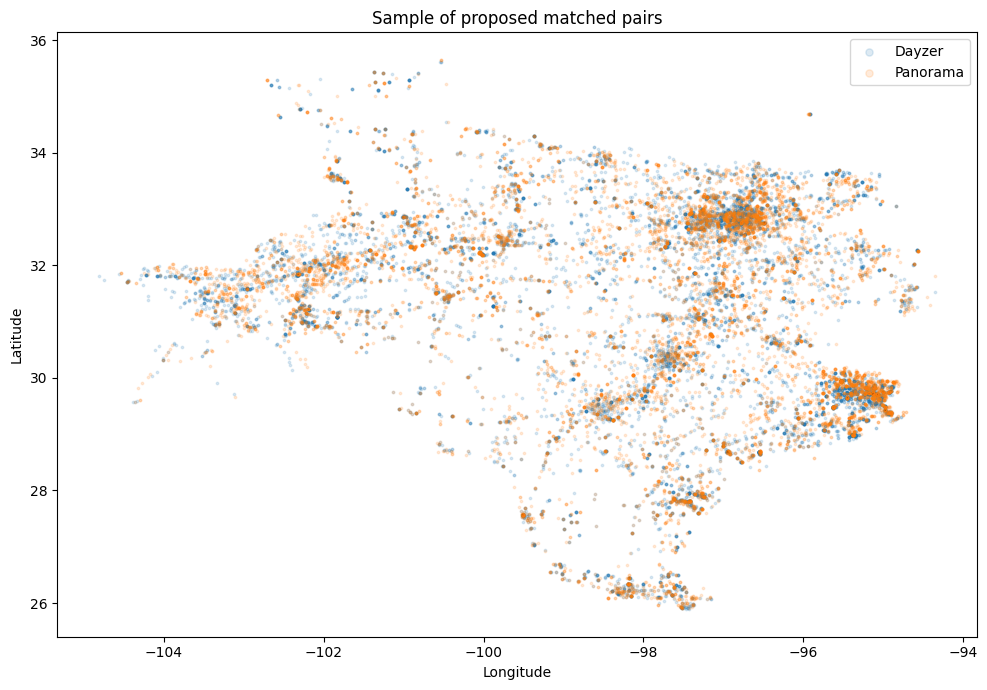

In [29]:
# Draw a light sample of matched-pair connectors to avoid overplotting.
plot_matches = matched.sort_values('composite_score', ascending=False).head(250)
plot_matches = plot_matches.merge(dayzer_bus[['dayzer_bus_id', 'latitude', 'longitude']], on='dayzer_bus_id', how='left')
plot_matches = plot_matches.merge(
    pano_bus[['pano_bus_id', 'latitude', 'longitude']], on='pano_bus_id', how='left', suffixes=('_dayzer', '_pano')
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(dayzer_bus['longitude'], dayzer_bus['latitude'], s=3, alpha=0.15, label='Dayzer')
ax.scatter(pano_bus['longitude'], pano_bus['latitude'], s=3, alpha=0.15, label='Panorama')
for _, row in plot_matches.dropna(subset=['latitude_dayzer', 'longitude_dayzer', 'latitude_pano', 'longitude_pano']).iterrows():
    ax.plot([row['longitude_dayzer'], row['longitude_pano']], [row['latitude_dayzer'], row['latitude_pano']], color='black', alpha=0.08, linewidth=0.5)
ax.set_title('Sample of proposed matched pairs')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=3)
plt.tight_layout()

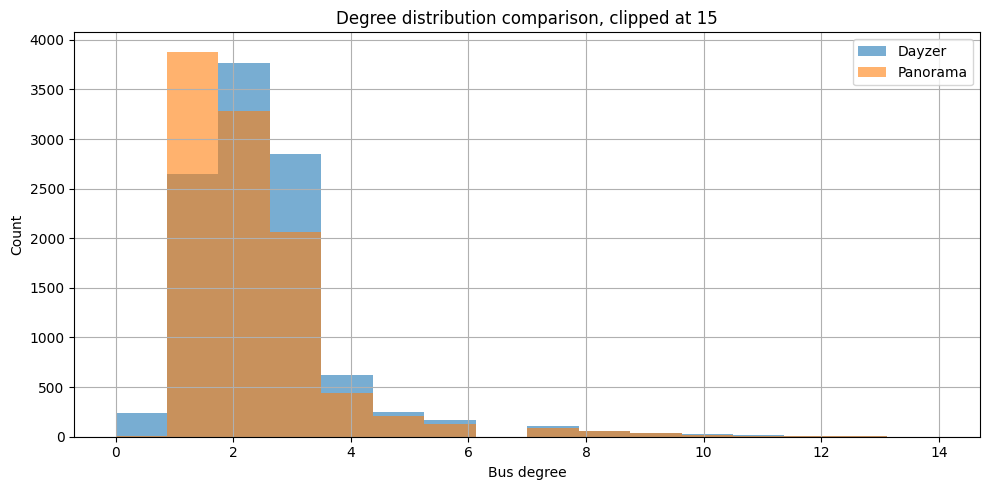

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
dayzer_graph_features['degree'].clip(upper=15).hist(bins=16, alpha=0.6, label='Dayzer', ax=ax)
pano_graph_features['degree'].clip(upper=15).hist(bins=16, alpha=0.6, label='Panorama', ax=ax)
ax.set_title('Degree distribution comparison, clipped at 15')
ax.set_xlabel('Bus degree')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()

## 12. Example Case Studies

The examples below are intended for audit, not proof of ground truth. They show how the scoring framework behaves for a high-confidence match, an ambiguous case, and a case where topology helps compensate for weaker name evidence.

In [31]:
high_case = results.query("confidence_label == 'high'").sort_values('composite_score', ascending=False).head(1)
ambiguous_case = results.query('ambiguity_flag == True').sort_values('composite_score', ascending=False).head(1)
topology_rescued = results[(results['name_score'] < 0.45) & (results['topology_score'] > 0.75) & results['pano_bus'].notna()].sort_values('composite_score', ascending=False).head(1)

case_studies = pd.concat([
    high_case.assign(case_type='high_confidence'),
    ambiguous_case.assign(case_type='ambiguous'),
    topology_rescued.assign(case_type='topology_rescued'),
], ignore_index=True)
case_studies[['case_type', 'dayzer_bus', 'pano_bus', 'distance_km', 'name_score', 'voltage_score', 'topology_score', 'composite_score', 'confidence_label', 'ambiguity_flag']]

,case_type,dayzer_bus,pano_bus,distance_km,name_score,voltage_score,topology_score,composite_score,confidence_label,ambiguity_flag
0,high_confidence,DEC_1_1,DEC_1KV_1,0.821806,0.841667,1.0,0.844444,0.917228,high,False
1,ambiguous,QALSW_13_1KV,QALSW_1KV_1,0.308851,0.669565,1.0,0.875000,0.887794,ambiguous,True
2,topology_rescued,SCLP_SCLPC_3,SCLPCOGN_13KV_3,0.221573,0.436111,1.0,0.900000,0.835723,high,False


## 13. Outputs

The reproducible run writes these deliverables:

- `assignment_3/outputs/bus_candidate_pairs.csv`
- `assignment_3/outputs/bus_mapping_results.csv`
- `assignment_3/outputs/bus_mapping_manual_review.csv`
- `assignment_3/reports/bus_mapping_summary.md`

The scored candidate file is also saved as `bus_candidate_pairs_scored.csv` for auditability.

In [32]:
for path in [
    OUTPUT_DIR / 'bus_candidate_pairs.csv',
    OUTPUT_DIR / 'bus_candidate_pairs_scored.csv',
    OUTPUT_DIR / 'bus_candidate_pairs_propagated.csv',
    OUTPUT_DIR / 'bus_mapping_results_baseline.csv',
    OUTPUT_DIR / 'bus_mapping_seed_matches.csv',
    OUTPUT_DIR / 'bus_mapping_accepted_graph_matches.csv',
    OUTPUT_DIR / 'bus_mapping_propagation_log.csv',
    OUTPUT_DIR / 'bus_mapping_results.csv',
    OUTPUT_DIR / 'bus_mapping_manual_review.csv',
    OUTPUT_DIR / 'bus_mapping_ablation_results.csv',
    OUTPUT_DIR / 'bus_mapping_sensitivity_results.csv',
    OUTPUT_DIR / 'bus_mapping_manual_review_extended.csv',
    OUTPUT_DIR / 'one_to_one_resolution_diagnostics.csv',
    OUTPUT_DIR / 'topology_contribution_summary.csv',
    OUTPUT_DIR / 'distance_voltage_diagnostics.csv',
    OUTPUT_DIR / 'bus_mapping_case_studies.csv',
    REPORT_DIR / 'bus_mapping_summary.md',
]:
    print(path.relative_to(REPO_ROOT), path.exists(), f'{path.stat().st_size / 1024 / 1024:.2f} MB' if path.exists() else '')

solution/assignment_3/outputs/bus_candidate_pairs.csv True 60.34 MB
solution/assignment_3/outputs/bus_candidate_pairs_scored.csv True 295.26 MB
solution/assignment_3/outputs/bus_candidate_pairs_propagated.csv True 329.32 MB
solution/assignment_3/outputs/bus_mapping_results_baseline.csv True 1.64 MB
solution/assignment_3/outputs/bus_mapping_seed_matches.csv True 0.02 MB
solution/assignment_3/outputs/bus_mapping_accepted_graph_matches.csv True 0.45 MB
solution/assignment_3/outputs/bus_mapping_propagation_log.csv True 0.00 MB
solution/assignment_3/outputs/bus_mapping_results.csv True 2.48 MB
solution/assignment_3/outputs/bus_mapping_manual_review.csv True 0.02 MB
solution/assignment_3/outputs/bus_mapping_ablation_results.csv True 0.00 MB
solution/assignment_3/outputs/bus_mapping_sensitivity_results.csv True 0.00 MB
solution/assignment_3/outputs/bus_mapping_manual_review_extended.csv True 0.05 MB
solution/assignment_3/outputs/one_to_one_resolution_diagnostics.csv True 0.00 MB
solution/assi